# Zomato Restaurant Rating Prediction & Market Intelligence

## 1. Project Introduction

This notebook explores a real-world restaurant dataset to understand which factors are associated with higher ratings and where the strongest market opportunities appear. The goal is to combine data cleaning, exploratory analysis, feature engineering, and machine learning in one portfolio-ready workflow.

**Business question**: Which restaurant characteristics are associated with stronger ratings, and how can a restaurant business use this information to improve positioning and customer experience?

**Analysis**: We will inspect the actual dataset, clean it carefully, examine market patterns, engineer predictive features, and train models to classify restaurants as high-rated or not.

**Visualization**: The notebook uses Matplotlib, Seaborn, and Plotly to tell a data story with both static and interactive visuals.

**Interpretation**: Findings are framed as observed relationships, not causal claims.

**Business insight**: The project is designed to help a fresher data analyst or data scientist explain, defend, and present every stage clearly in an interview.

In [1]:
import os
import json
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from IPython.display import HTML, display

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# One dataset path variable near the top for easy adjustments
project_dir = Path.cwd()
dataset_candidates = [
    project_dir / 'zomato.csv',
    project_dir / 'Zomato Restaurant Dataset.csv',
    project_dir / 'Zomato Restaurant dataset.csv',
]
dataset_path = next((p for p in dataset_candidates if p.exists()), None)
if dataset_path is None:
    csv_files = sorted(project_dir.glob('*.csv'))
    dataset_path = csv_files[0] if csv_files else None

print('Project directory:', project_dir)
print('Dataset path:', dataset_path)
if dataset_path is None:
    raise FileNotFoundError('No CSV file was found in the project directory. Place the dataset in zomato.csv or update DATASET_CANDIDATES.')

df = pd.read_csv(dataset_path)
print(f'Loaded dataset shape: {df.shape}')
print('Columns:', list(df.columns))
df_raw = df.copy()

Project directory: C:\Users\DELL\Desktop\Zomato Market Analysis
Dataset path: C:\Users\DELL\Desktop\Zomato Market Analysis\zomato.csv
Loaded dataset shape: (9551, 21)
Columns: ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


## 2. Business Problem

### BUSINESS QUESTION
How do restaurant characteristics such as location, cuisine, pricing, digital adoption, and customer engagement relate to restaurant ratings?

### ANALYSIS
We will study the actual distribution of restaurant ratings and identify which patterns are strongly associated with high ratings.

### VISUALIZATION
The notebook visualizes rating distribution, location strength, cuisine popularity, and digital adoption trends.

### INTERPRETATION
We will interpret the observed relationships as associations rather than causal effects.

### BUSINESS INSIGHT
This helps restaurant owners and analysts identify market positioning strategies based on real patterns in the data.

In [2]:
print('Shape:', df.shape)
display(df.head())
print('\nColumns:')
print(list(df.columns))
print('\nData types:')
print(df.dtypes.to_string())
print('\nMissing values:')
print(df.isna().sum().to_string())
print('\nDuplicates:', df.duplicated().sum())
print('\nImportant categorical unique counts:')
for col in [c for c in df.columns if df[c].dtype == 'object'][:12]:
    print(f'{col}: {df[col].nunique()} unique values')
print('\nDescriptive statistics for numeric columns:')
display(df.describe(include=[np.number]).T)

Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229



Columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Data types:
Restaurant ID             int64
Restaurant Name             str
Country Code              int64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude               float64
Latitude                float64
Cuisines                    str
Average Cost for two      int64
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range               int64
Aggregate rating        float64
Rating color                str
Rating text                 

,count,mean,std,min,25%,50%,75%,max
Restaurant ID,9551.0,9.051128e+06,8.791521e+06,53.000000,301962.500000,6.004089e+06,1.835229e+07,1.850065e+07
Country Code,9551.0,1.836562e+01,5.675055e+01,1.000000,1.000000,1.000000e+00,1.000000e+00,2.160000e+02
Longitude,9551.0,6.412657e+01,4.146706e+01,-157.948486,77.081343,7.719196e+01,7.728201e+01,1.748321e+02
Latitude,9551.0,2.585438e+01,1.100794e+01,-41.330428,28.478713,2.857047e+01,2.864276e+01,5.597698e+01
Average Cost for two,9551.0,1.199211e+03,1.612118e+04,0.000000,250.000000,4.000000e+02,7.000000e+02,8.000000e+05
Price range,9551.0,1.804837e+00,9.056088e-01,1.000000,1.000000,2.000000e+00,2.000000e+00,4.000000e+00
Aggregate rating,9551.0,2.666370e+00,1.516378e+00,0.000000,2.500000,3.200000e+00,3.700000e+00,4.900000e+00
Votes,9551.0,1.569097e+02,4.301691e+02,0.000000,5.000000,3.100000e+01,1.310000e+02,1.093400e+04


## 3. Dataset Overview

### BUSINESS QUESTION
What is the real state of the data before modeling?

### ANALYSIS
The dataset contains many restaurant-level features, including ratings, city, locality, cuisines, cost, and digital-order behavior. We inspect the schema before deciding what is valid for cleaning and prediction.

### VISUALIZATION
We review the raw structure and data quality instead of assuming a standard schema.

### INTERPRETATION
The dataset shows a real-world mix of valid ratings, missing cuisine values, and zero-value rating records that must be treated carefully.

### BUSINESS INSIGHT
The cleaning step is not cosmetic; it protects the quality of the prediction model and the reliability of the market analysis.

In [3]:
df_before = df.copy()
print('Before cleaning:')
print(f'Rows: {df_before.shape[0]}')
print(f'Columns: {df_before.shape[1]}')
print('Missing values:')
print(df_before.isna().sum().to_string())
print('Zero rating records:', (df_before['Aggregate rating'] == 0).sum())
if 'Cuisines' in df_before.columns:
    print('Missing cuisines:', df_before['Cuisines'].isna().sum())
print('Duplicate rows:', df_before.duplicated().sum())

Before cleaning:
Rows: 9551
Columns: 21
Missing values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Zero rating records: 2148
Missing cuisines: 9


Duplicate rows: 0


## 4. Data Cleaning

### BUSINESS QUESTION
How should the dataset be cleaned to make analysis and modeling reliable?

### ANALYSIS
Important cleaning decisions include handling missing cuisines, converting zero ratings to missing values, normalizing yes/no fields, and reducing noise in pricing and cuisine text.

### VISUALIZATION
We compare the raw dataset to the cleaned one using shape and missing-value summaries.

### INTERPRETATION
We do not delete rows unnecessarily. Instead, we keep the dataset intact while correcting invalid categories and recording missing values where they should remain missing.

### BUSINESS INSIGHT
This preserves data quality without harming the real business signal in the dataset.

In [4]:
# Clean a copy of the raw dataset
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

# Remove duplicate rows
df = df.drop_duplicates().copy()

# Normalize text columns
for col in ['Restaurant Name', 'City', 'Address', 'Locality', 'Locality Verbose', 'Cuisines', 'Currency']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown').astype(str).str.strip()

# Standardize rating and cost
for col in ['Aggregate rating', 'Average Cost for two', 'Votes', 'Price range']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Treat zero ratings as missing because a zero does not represent a valid restaurant rating in this dataset
if 'Aggregate rating' in df.columns:
    df['Aggregate rating'] = df['Aggregate rating'].replace(0, np.nan)

# Fill missing cuisines sensibly
if 'Cuisines' in df.columns:
    df['Cuisines'] = df['Cuisines'].fillna('Unknown').astype(str).str.replace('\s+', ' ', regex=True)
    df.loc[df['Cuisines'].str.strip().eq(''), 'Cuisines'] = 'Unknown'

# Clean yes/no fields
for col in ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()
        df[col] = df[col].replace({'Yes': 'Yes', 'No': 'No', 'Y': 'Yes', 'N': 'No', 'Nan': 'No'})

# Standardize cost strings if present
if 'Average Cost for two' in df.columns:
    df['Average Cost for two'] = pd.to_numeric(df['Average Cost for two'], errors='coerce')
    df['Average Cost for two'] = df['Average Cost for two'].fillna(df['Average Cost for two'].median())

# Standardize cuisine names to clean occasional duplications and stray spacing
if 'Cuisines' in df.columns:
    df['Cuisines'] = df['Cuisines'].str.replace(' ,', ',', regex=False).str.replace(', ', ',', regex=False)

print('After cleaning:')
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print('Missing values:')
print(df.isna().sum().to_string())
print('Zero rating records after cleaning:', (df['Aggregate rating'] == 0).sum())

# Show a brief comparison
before_missing = df_before.isna().sum().sum()
after_missing = df.isna().sum().sum()
print(f'Missing values before: {before_missing}')
print(f'Missing values after: {after_missing}')

After cleaning:


Rows: 9551
Columns: 21
Missing values:
Restaurant ID              0
Restaurant Name            0
Country Code               0
City                       0
Address                    0
Locality                   0
Locality Verbose           0
Longitude                  0
Latitude                   0
Cuisines                   0
Average Cost for two       0
Currency                   0
Has Table booking          0
Has Online delivery        0
Is delivering now          0
Switch to order menu       0
Price range                0
Aggregate rating        2148
Rating color               0
Rating text                0
Votes                      0
Zero rating records after cleaning: 0
Missing values before: 9
Missing values after: 2148


<>:24: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:24: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\DELL\AppData\Local\Temp\ipykernel_8260\2502940564.py:24: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df['Cuisines'] = df['Cuisines'].fillna('Unknown').astype(str).str.replace('\s+', ' ', regex=True)


## 5. Exploratory Data Analysis

### BUSINESS QUESTION
What patterns stand out in the restaurant market?

### ANALYSIS
We look at restaurant counts, ratings, pricing, and digital adoption across the dataset.

### VISUALIZATION
The next sections use static and interactive charts to highlight the strongest patterns.

### INTERPRETATION
The analysis focuses on observed relationships and business relevance rather than assumptions.

### BUSINESS INSIGHT
This creates a strong foundation for business recommendations and risk-aware model interpretation.

Total Restaurants: 9551
Cities: 141
Average Rating: 3.44
Average Cost for Two: 1199.21
Online Order %: 25.66
Table Booking %: 12.12


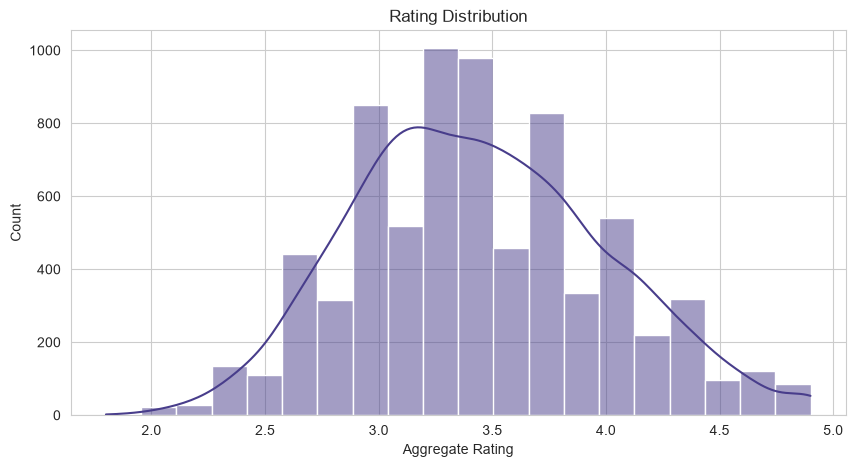

C:\Users\DELL\AppData\Local\Temp\ipykernel_8260\3151192607.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis')
C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


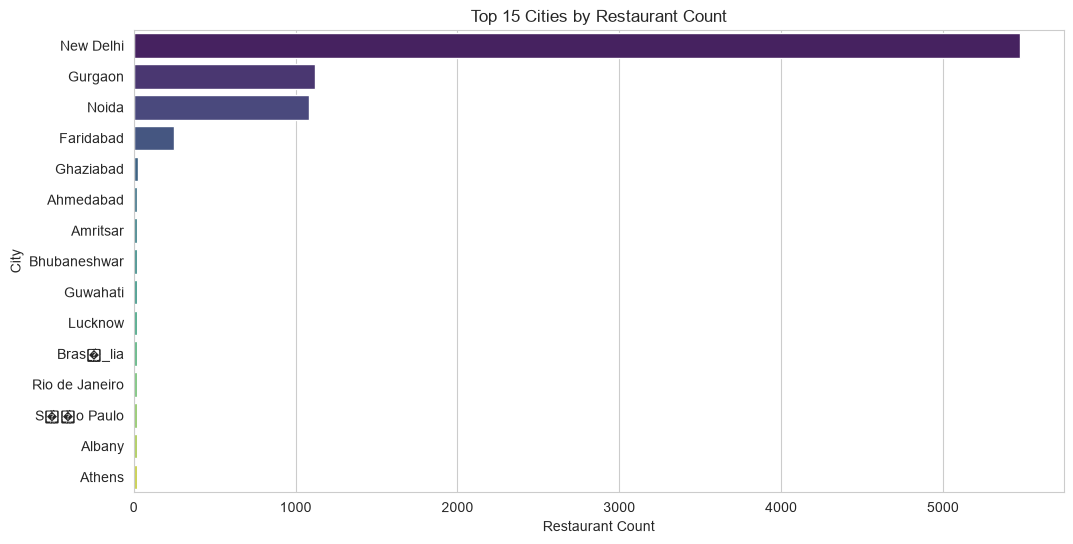

C:\Users\DELL\AppData\Local\Temp\ipykernel_8260\3151192607.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, palette='magma')


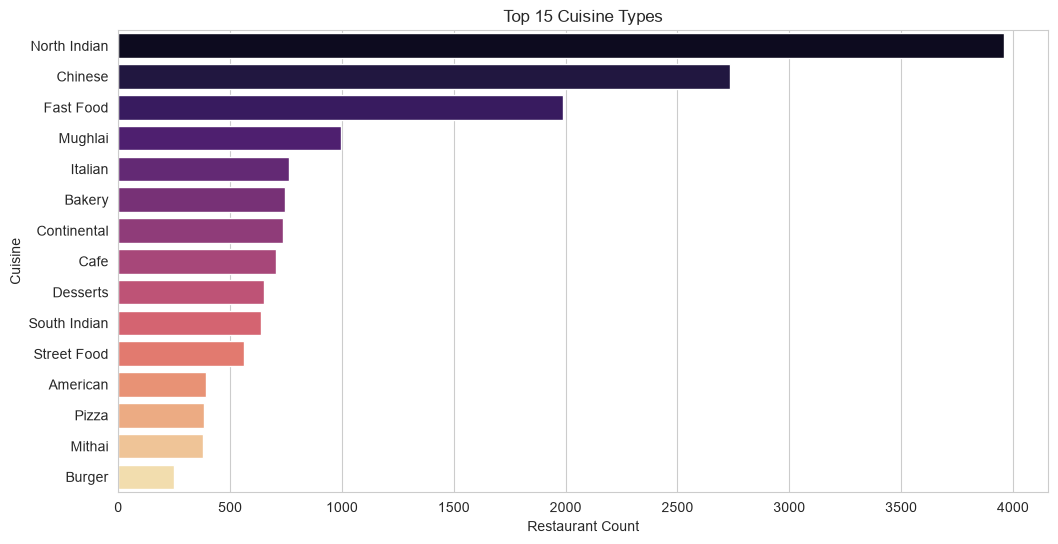

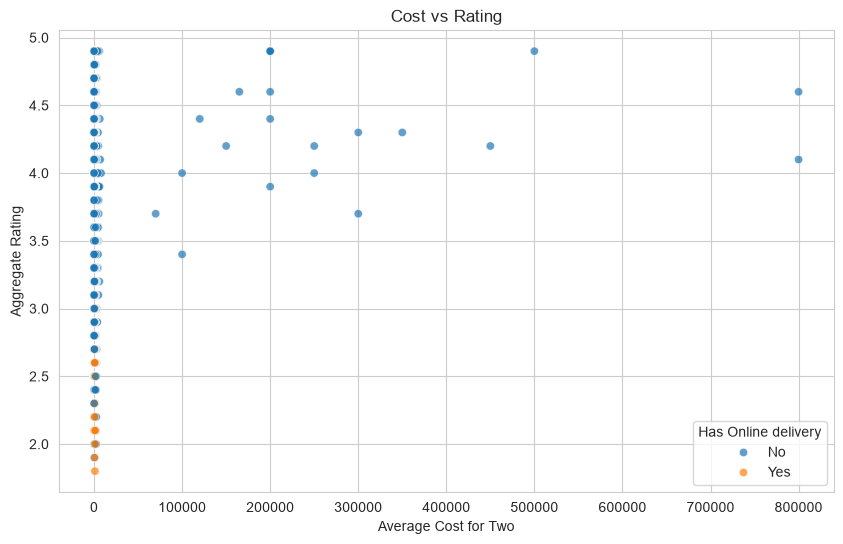

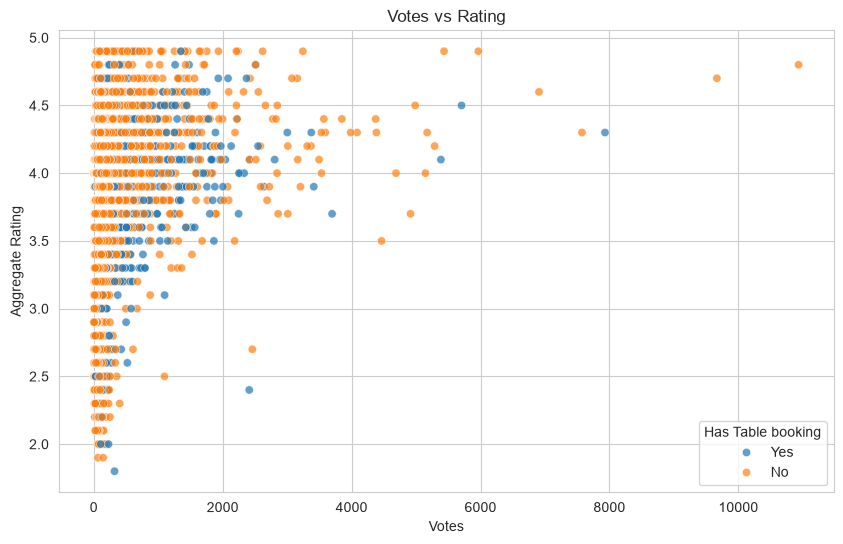

In [5]:
market_overview = {
    'Total Restaurants': df.shape[0],
    'Cities': df['City'].nunique() if 'City' in df.columns else np.nan,
    'Average Rating': round(df['Aggregate rating'].mean(), 2) if 'Aggregate rating' in df.columns else np.nan,
    'Average Cost for Two': round(df['Average Cost for two'].mean(), 2) if 'Average Cost for two' in df.columns else np.nan,
    'Online Order %': round((df['Has Online delivery'].eq('Yes').mean() * 100), 2) if 'Has Online delivery' in df.columns else np.nan,
    'Table Booking %': round((df['Has Table booking'].eq('Yes').mean() * 100), 2) if 'Has Table booking' in df.columns else np.nan,
}
for key, value in market_overview.items():
    print(f'{key}: {value}')

if 'Aggregate rating' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df['Aggregate rating'].dropna(), bins=20, kde=True, color='darkslateblue')
    plt.title('Rating Distribution')
    plt.xlabel('Aggregate Rating')
    plt.ylabel('Count')
    plt.show()

if 'City' in df.columns:
    city_counts = df['City'].value_counts().head(15)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis')
    plt.title('Top 15 Cities by Restaurant Count')
    plt.xlabel('Restaurant Count')
    plt.ylabel('City')
    plt.show()

if 'Cuisines' in df.columns:
    cuisine_counts = df['Cuisines'].str.split(',').explode().str.strip().value_counts().head(15)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, palette='magma')
    plt.title('Top 15 Cuisine Types')
    plt.xlabel('Restaurant Count')
    plt.ylabel('Cuisine')
    plt.show()

if 'Average Cost for two' in df.columns and 'Aggregate rating' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Average Cost for two', y='Aggregate rating', hue='Has Online delivery', alpha=0.7)
    plt.title('Cost vs Rating')
    plt.xlabel('Average Cost for Two')
    plt.ylabel('Aggregate Rating')
    plt.show()

if 'Votes' in df.columns and 'Aggregate rating' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Votes', y='Aggregate rating', hue='Has Table booking', alpha=0.7)
    plt.title('Votes vs Rating')
    plt.xlabel('Votes')
    plt.ylabel('Aggregate Rating')
    plt.show()

In [6]:
# Interactive plotly charts for location, cuisines, cost vs rating, votes vs rating, online order comparison

if 'City' in df.columns:
    city_counts = df['City'].value_counts().reset_index()
    city_counts.columns = ['City', 'Restaurants']
    fig_city = px.bar(city_counts.head(15), x='Restaurants', y='City', orientation='h', color='Restaurants',
                      title='Interactive Restaurant Count by City', hover_name='City')
    fig_city.update_layout(template='plotly_white', xaxis_title='Restaurant Count', yaxis_title='City')
    fig_city.show()

if 'Cuisines' in df.columns:
    cuisine_counts = df['Cuisines'].str.split(',').explode().str.strip().str.title().value_counts().reset_index()
    cuisine_counts.columns = ['Cuisine', 'Count']
    fig_cuisine = px.bar(cuisine_counts.head(15), x='Count', y='Cuisine', orientation='h', color='Count',
                         title='Interactive Cuisine Popularity')
    fig_cuisine.update_layout(template='plotly_white', xaxis_title='Count', yaxis_title='Cuisine')
    fig_cuisine.show()

if 'Average Cost for two' in df.columns and 'Aggregate rating' in df.columns:
    fig_cost_rating = px.scatter(df, x='Average Cost for two', y='Aggregate rating', color='Has Online delivery',
                                hover_data=['City', 'Cuisines', 'Votes'], title='Interactive Cost vs Rating',
                                labels={'Average Cost for two': 'Average Cost for Two', 'Aggregate rating': 'Aggregate Rating'})
    fig_cost_rating.update_layout(template='plotly_white')
    fig_cost_rating.show()

if 'Votes' in df.columns and 'Aggregate rating' in df.columns:
    fig_votes_rating = px.scatter(df, x='Votes', y='Aggregate rating', color='Has Table booking',
                                hover_data=['City', 'Cuisines'], title='Interactive Votes vs Rating',
                                labels={'Votes': 'Votes', 'Aggregate rating': 'Aggregate Rating'})
    fig_votes_rating.update_layout(template='plotly_white')
    fig_votes_rating.show()

# Online order vs rating
if 'Has Online delivery' in df.columns and 'Aggregate rating' in df.columns:
    online_df = df.dropna(subset=['Aggregate rating']).groupby('Has Online delivery')['Aggregate rating'].mean().reset_index()
    fig_online = px.bar(online_df, x='Has Online delivery', y='Aggregate rating', color='Has Online delivery',
                       title='Average Rating by Online Ordering Availability',
                       labels={'Aggregate rating': 'Average Rating'})
    fig_online.update_layout(template='plotly_white')
    fig_online.show()

# Table booking vs rating
if 'Has Table booking' in df.columns and 'Aggregate rating' in df.columns:
    table_df = df.dropna(subset=['Aggregate rating']).groupby('Has Table booking')['Aggregate rating'].mean().reset_index()
    fig_table = px.bar(table_df, x='Has Table booking', y='Aggregate rating', color='Has Table booking',
                       title='Average Rating by Table Booking Availability',
                       labels={'Aggregate rating': 'Average Rating'})
    fig_table.update_layout(template='plotly_white')
    fig_table.show()

## 6. Feature Engineering

### BUSINESS QUESTION
Which features are most useful for predicting whether a restaurant is highly rated?

### ANALYSIS
We create practical features that are supported by the dataset and avoid leakage from the original rating.

### VISUALIZATION
The engineered features are reviewed for their relationship with the target.

### INTERPRETATION
Each feature is built from real business signals such as price level, cuisine mix, customer engagement, and digital adoption.

### BUSINESS INSIGHT
These features make the modeling task easier to explain and defend in interviews.

In [7]:
# Build a cleaned working dataset for modeling
df_model = df.copy()

# Use a defensible threshold based on the dataset: > = 4.0 starts the 'Very Good' range and keeps the target meaningful
df_model['High_Rated'] = (df_model['Aggregate rating'] >= 4.0).astype(int)

if 'Cuisines' in df_model.columns:
    df_model['cuisine_count'] = df_model['Cuisines'].fillna('Unknown').str.split(',').str.len()
    df_model['cuisine_frequency'] = df_model['Cuisines'].map(df_model['Cuisines'].value_counts())

if 'City' in df_model.columns:
    df_model['location_frequency'] = df_model['City'].map(df_model['City'].value_counts())

if 'Average Cost for two' in df_model.columns:
    df_model['price_category'] = pd.qcut(df_model['Average Cost for two'], q=3, labels=['Low', 'Medium', 'High'])
    df_model['price_category'] = df_model['price_category'].astype(str)

if 'Votes' in df_model.columns:
    df_model['votes_log'] = np.log1p(df_model['Votes'].fillna(0))

if 'Has Online delivery' in df_model.columns:
    df_model['has_online_order'] = df_model['Has Online delivery'].map({'Yes': 1, 'No': 0, 'nan': 0})

if 'Has Table booking' in df_model.columns:
    df_model['has_table_booking'] = df_model['Has Table booking'].map({'Yes': 1, 'No': 0, 'nan': 0})

# Use only supported features for modeling
supported_feature_cols = [
    'Average Cost for two', 'Votes', 'votes_log', 'cuisine_count', 'cuisine_frequency', 'location_frequency',
    'has_online_order', 'has_table_booking', 'price_category', 'City'
]
feature_columns = [col for col in supported_feature_cols if col in df_model.columns]
target_col = 'High_Rated'

df_model = df_model.dropna(subset=[target_col] + [col for col in feature_columns if col not in ['City', 'price_category']])
print('Target distribution:')
print(df_model[target_col].value_counts().to_string())
print('\nClass percentages:')
print((df_model[target_col].value_counts(normalize=True) * 100).round(2).to_string())
print('\nFeature columns selected for modeling:')
print(feature_columns)

Target distribution:
High_Rated
0    8171
1    1380

Class percentages:
High_Rated
0    85.55
1    14.45

Feature columns selected for modeling:
['Average Cost for two', 'Votes', 'votes_log', 'cuisine_count', 'cuisine_frequency', 'location_frequency', 'has_online_order', 'has_table_booking', 'price_category', 'City']


## 7. Target Variable

### BUSINESS QUESTION
What is the most defensible definition of a high-rated restaurant in this data?

### ANALYSIS
The raw rating distribution includes a large number of restaurants rated below 4.0, while 4.0 and above begins the strong performance zone. We therefore define a highly rated restaurant as one with an aggregate rating of at least 4.0.

### VISUALIZATION
A chart of the target distribution helps assess class balance before training.

### INTERPRETATION
The target is not perfectly balanced, but it is meaningful and not extreme. This makes classification appropriate for the data at hand.

### BUSINESS INSIGHT
The classification problem is realistic and aligned with how restaurants and customers describe quality in the market.

C:\Users\DELL\AppData\Local\Temp\ipykernel_8260\1334804175.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_model, x='High_Rated', palette='Set2')


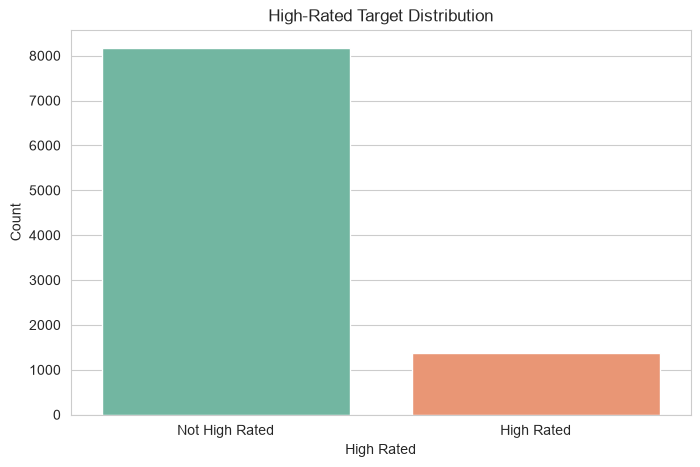

High_Rated
0    85.55
1    14.45


In [8]:
if 'Aggregate rating' in df_model.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_model, x='High_Rated', palette='Set2')
    plt.title('High-Rated Target Distribution')
    plt.xlabel('High Rated')
    plt.ylabel('Count')
    plt.xticks([0, 1], ['Not High Rated', 'High Rated'])
    plt.show()

    target_pct = df_model['High_Rated'].value_counts(normalize=True) * 100
    print(target_pct.round(2).to_string())

## 8. Machine Learning

### BUSINESS QUESTION
Can we build a model that predicts whether a restaurant is high-rated using real business features?

### ANALYSIS
We train several common classification models using a clean preprocessing pipeline and stratified train/test split.

### VISUALIZATION
We compare model results using a pipeline that handles missing values and one-hot encodes categorical variables.

### INTERPRETATION
The model is built to support explainable and interview-friendly decision-making.

### BUSINESS INSIGHT
The best model should be chosen using balanced metrics such as F1 score and ROC-AUC, not only accuracy.

In [9]:
# Build feature matrix and target
X = df_model[feature_columns].copy()
y = df_model[target_col].copy()

# Fill missing values in the selected features optimistically for the model
for col in X.columns:
    if X[col].isna().any():
        if pd.api.types.is_numeric_dtype(X[col]):
            X[col] = X[col].fillna(X[col].median())
        else:
            X[col] = X[col].fillna('Unknown')

# Define numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_leaf=10),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', min_samples_leaf=5),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

model_results = []
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    model_results.append(metrics)
    print(f'\n{name}')
    print(classification_report(y_test, y_pred, target_names=['Not High Rated', 'High Rated']))
    print('ROC-AUC:', round(metrics['ROC-AUC'], 4))

model_results_df = pd.DataFrame(model_results).sort_values(['F1', 'ROC-AUC', 'Accuracy'], ascending=False).reset_index(drop=True)
print('\nModel comparison table:')
display(model_results_df)
best_model_name = model_results_df.iloc[0]['Model']
best_model = models[best_model_name]
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', best_model)])
best_pipeline.fit(X_train, y_train)
print(f'\nBest model selected: {best_model_name}')


Logistic Regression
                precision    recall  f1-score   support

Not High Rated       0.97      0.87      0.92      2043
    High Rated       0.53      0.86      0.65       345

      accuracy                           0.87      2388
     macro avg       0.75      0.86      0.78      2388
  weighted avg       0.91      0.87      0.88      2388

ROC-AUC: 0.9443



Decision Tree
                precision    recall  f1-score   support

Not High Rated       0.92      0.97      0.94      2043
    High Rated       0.73      0.50      0.59       345

      accuracy                           0.90      2388
     macro avg       0.82      0.73      0.77      2388
  weighted avg       0.89      0.90      0.89      2388

ROC-AUC: 0.9126



Random Forest
                precision    recall  f1-score   support

Not High Rated       0.98      0.86      0.91      2043
    High Rated       0.52      0.89      0.65       345

      accuracy                           0.86      2388
     macro avg       0.75      0.87      0.78      2388
  weighted avg       0.91      0.86      0.88      2388

ROC-AUC: 0.9421



Gradient Boosting
                precision    recall  f1-score   support

Not High Rated       0.93      0.98      0.95      2043
    High Rated       0.80      0.59      0.68       345

      accuracy                           0.92      2388
     macro avg       0.87      0.78      0.82      2388
  weighted avg       0.91      0.92      0.91      2388

ROC-AUC: 0.943

Model comparison table:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.919179,0.801587,0.585507,0.676717,0.943030
1,Random Forest,0.863065,0.515152,0.886957,0.651757,0.942081
2,Logistic Regression,0.867672,0.525847,0.855072,0.651214,0.944349
3,Decision Tree,0.900335,0.725738,0.498551,0.591065,0.912556



Best model selected: Gradient Boosting


## 9. Model Comparison

### BUSINESS QUESTION
Which model performs best on the actual restaurant data?

### ANALYSIS
We compare models using multiple metrics, with F1 score and ROC-AUC given more importance than accuracy alone.

### VISUALIZATION
We create a comparison bar chart and an interactive Plotly comparison chart.

### INTERPRETATION
A model that performs well on minority-class detection is more valuable than a model with a slightly higher raw accuracy but weaker recall.

### BUSINESS INSIGHT
This keeps the business decision grounded in meaningful prediction quality rather than leaderboard-style numbers.

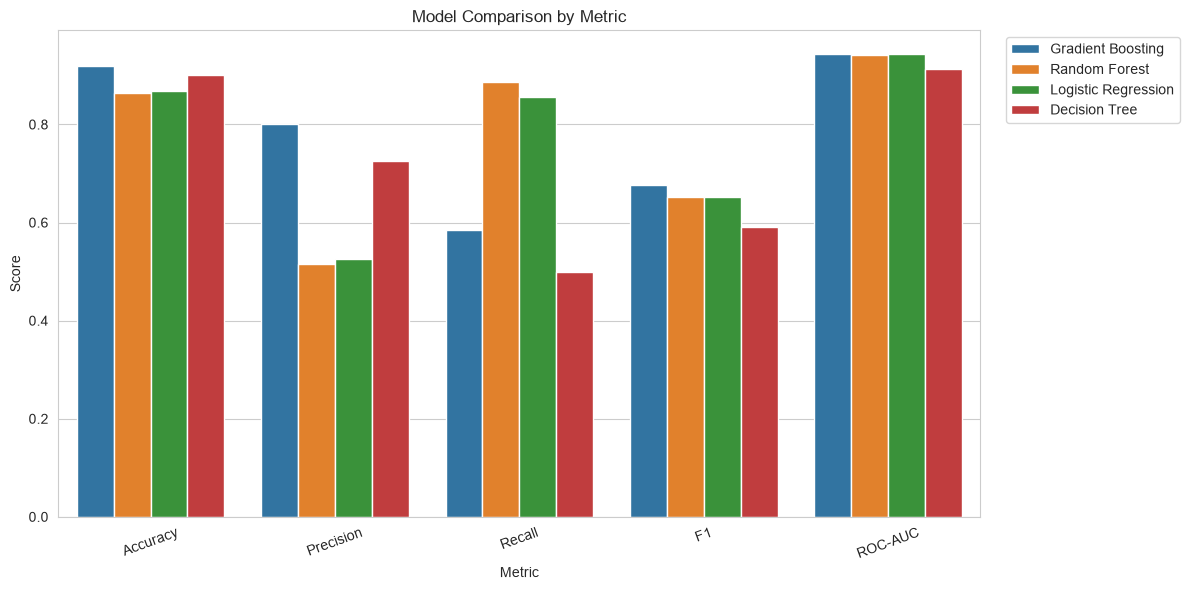

In [10]:
# Plot model comparison
model_metric_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
comparison_chart = model_results_df[model_metric_cols].melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_chart, x='Metric', y='Score', hue='Model')
plt.title('Model Comparison by Metric')
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

fig_model_compare = px.bar(
    comparison_chart,
    x='Metric',
    y='Score',
    color='Model',
    barmode='group',
    title='Interactive Model Comparison',
    labels={'Score': 'Score', 'Metric': 'Metric'}
)
fig_model_compare.update_layout(template='plotly_white')
fig_model_compare.show()

## 10. Model Evaluation

### BUSINESS QUESTION
How well does the selected model actually classify highly rated restaurants?

### ANALYSIS
We evaluate the best model using confusion matrix, precision, recall, F1, and ROC-AUC.

### VISUALIZATION
We create a confusion matrix and ROC curve for the best model.

### INTERPRETATION
Model performance is interpreted in the context of business risk and the class imbalance in the target.

### BUSINESS INSIGHT
The selected model should be strong enough to support practical recommendations while being transparent about its limits.

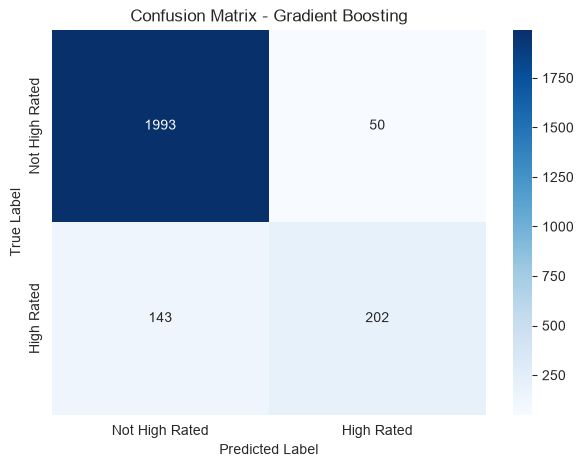

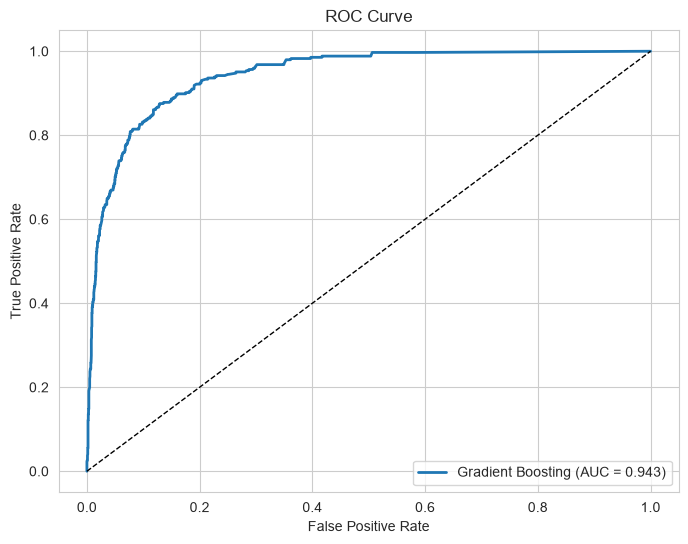

C:\Users\DELL\AppData\Local\Temp\ipykernel_8260\1929602171.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


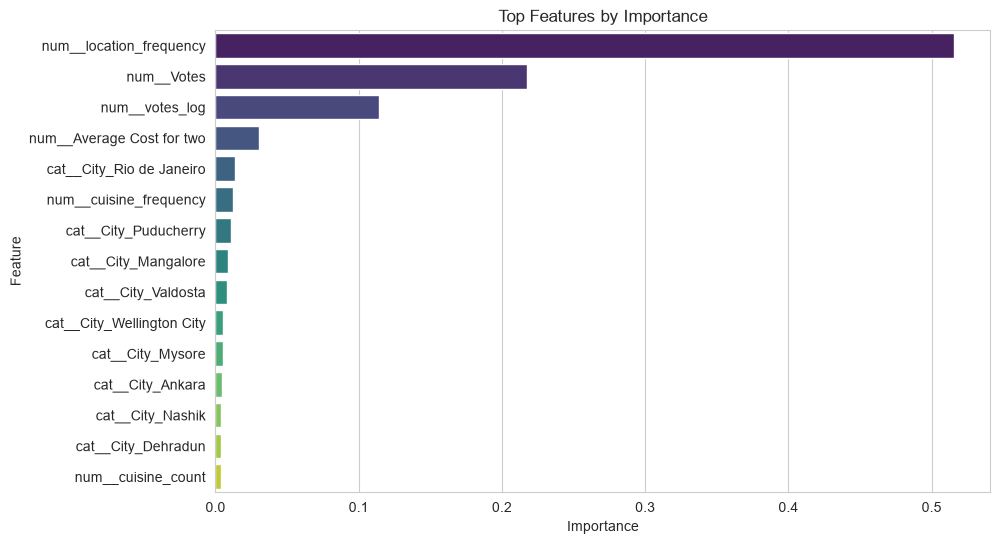

Best model metrics:
{'Model': 'Gradient Boosting', 'Accuracy': 0.919179229480737, 'Precision': 0.8015873015873016, 'Recall': 0.5855072463768116, 'F1': 0.6767169179229481, 'ROC-AUC': 0.9430299289904731}


In [11]:
# Evaluate selected model
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', models[best_model_name])])
best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not High Rated', 'High Rated'], yticklabels=['Not High Rated', 'High Rated'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc_score(y_test, y_proba_best):.3f})', lw=2)
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Feature importance if supported
if hasattr(best_pipeline.named_steps['model'], 'feature_importances_'):
    encoded_features = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importances = best_pipeline.named_steps['model'].feature_importances_
    feat_df = pd.DataFrame({'Feature': encoded_features, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
    plt.title('Top Features by Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

best_metrics = {
    'Model': best_model_name,
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best, zero_division=0),
    'Recall': recall_score(y_test, y_pred_best, zero_division=0),
    'F1': f1_score(y_test, y_pred_best, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_proba_best)
}
print('Best model metrics:')
print(best_metrics)

## 11. Interactive Visual Analytics

### BUSINESS QUESTION
Which interactive patterns are most useful for business storytelling and presentation?

### ANALYSIS
We turn the core findings into interactive Plotly charts with hover details and filtering options.

### VISUALIZATION
The following sections are designed to feel like a modern data-storytelling dashboard.

### INTERPRETATION
These charts provide a polished way to explain the market story to stakeholders.

### BUSINESS INSIGHT
This is where the notebook shifts from analysis to portfolio-style communication.

In [12]:
# Interactive rating distribution
rating_fig = px.histogram(df_model, x='Aggregate rating', nbins=30, title='Interactive Rating Distribution',
                         labels={'Aggregate rating': 'Rating'}, color_discrete_sequence=['#6A5ACD'])
rating_fig.update_layout(template='plotly_white')
rating_fig.show()

# Interactive location analysis
if 'City' in df_model.columns:
    location_summary = df_model.groupby('City').agg(
        restaurants=('City', 'size'),
        avg_rating=('Aggregate rating', 'mean'),
        avg_cost=('Average Cost for two', 'mean')
    ).reset_index().sort_values('restaurants', ascending=False).head(20)
    location_fig = px.scatter(location_summary, x='restaurants', y='avg_rating', size='avg_cost', color='avg_rating',
                             hover_name='City', title='Interactive Location Analysis',
                             labels={'restaurants': 'Restaurants', 'avg_rating': 'Average Rating', 'avg_cost': 'Average Cost'})
    location_fig.update_layout(template='plotly_white')
    location_fig.show()

# Interactive cuisine analysis
if 'Cuisines' in df_model.columns:
    cuisine_summary = df_model.assign(cuisine_split=df_model['Cuisines'].str.split(',')).explode('cuisine_split')
    cuisine_summary['cuisine_split'] = cuisine_summary['cuisine_split'].str.strip().str.title()
    cuisine_summary = cuisine_summary.groupby('cuisine_split').agg(
        popularity=('cuisine_split', 'size'),
        avg_rating=('Aggregate rating', 'mean'),
        avg_cost=('Average Cost for two', 'mean')
    ).reset_index().sort_values('popularity', ascending=False).head(20)
    cuisine_fig = px.scatter(cuisine_summary, x='popularity', y='avg_rating', size='avg_cost', color='avg_rating',
                            hover_name='cuisine_split', title='Interactive Cuisine Analysis',
                            labels={'popularity': 'Popularity', 'avg_rating': 'Average Rating', 'avg_cost': 'Average Cost'})
    cuisine_fig.update_layout(template='plotly_white')
    cuisine_fig.show()

# Interactive votes vs rating
fig_votes = px.scatter(df_model, x='Votes', y='Aggregate rating', color='High_Rated', hover_data=['City', 'Cuisines'],
                      title='Interactive Votes vs Rating', labels={'Aggregate rating': 'Rating'})
fig_votes.update_layout(template='plotly_white')
fig_votes.show()

# Interactive online-order comparison
if 'Has Online delivery' in df_model.columns:
    online_summary = df_model.groupby('Has Online delivery').agg(avg_rating=('Aggregate rating', 'mean'), count=('Aggregate rating', 'size')).reset_index()
    fig_online = px.bar(online_summary, x='Has Online delivery', y='avg_rating', color='Has Online delivery',
                       title='Average Rating by Online Delivery', hover_data=['count'])
    fig_online.update_layout(template='plotly_white')
    fig_online.show()

# Interactive table-booking comparison
if 'Has Table booking' in df_model.columns:
    table_summary = df_model.groupby('Has Table booking').agg(avg_rating=('Aggregate rating', 'mean'), count=('Aggregate rating', 'size')).reset_index()
    fig_table = px.bar(table_summary, x='Has Table booking', y='avg_rating', color='Has Table booking',
                       title='Average Rating by Table Booking', hover_data=['count'])
    fig_table.update_layout(template='plotly_white')
    fig_table.show()

In [13]:
# Build a polished notebook hero section using HTML and CSS
market_pulse = {
    'Restaurants Analyzed': df_model.shape[0],
    'Locations': df_model['City'].nunique() if 'City' in df_model.columns else 0,
    'Average Rating': round(df_model['Aggregate rating'].mean(), 2),
    'Average Cost': round(df_model['Average Cost for two'].mean(), 2),
    'Best Model': best_model_name,
    'F1 Score': round(best_metrics['F1'], 3),
}

hero_html = f'''
<style>
 body {{ font-family: 'Segoe UI', Arial, sans-serif; background: linear-gradient(135deg, #0c0f1a, #121b2d 40%, #17131f); color: #edf3ff; }}
 .hero {{ padding: 32px 24px 18px; background: rgba(255,255,255,0.04); border: 1px solid rgba(255,255,255,0.08); border-radius: 22px; box-shadow: 0 18px 45px rgba(0,0,0,0.25); }}
 .eyebrow {{ letter-spacing: 0.18em; text-transform: uppercase; font-size: 12px; color: #7dc6ff; margin-bottom: 12px; }}
 h1 {{ font-size: 3.0rem; line-height: 1.0; margin: 0; font-weight: 700; }}
 .subtitle {{ color: #dfe8ff; font-size: 1.15rem; margin-top: 14px; max-width: 850px; }}
 .card-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(160px, 1fr)); gap: 14px; margin-top: 22px; }}
 .metric-card {{ background: linear-gradient(135deg, rgba(23,38,67,0.9), rgba(66,96,140,0.5)); border: 1px solid rgba(255,255,255,0.08); border-radius: 18px; padding: 16px; min-height: 120px; }}
 .metric-label {{ font-size: 12px; letter-spacing: 0.12em; text-transform: uppercase; color: #a4d0ff; }}
 .metric-value {{ font-size: 2rem; font-weight: 700; margin-top: 10px; color: #ffffff; }}
 .section-tag {{ margin-top: 24px; letter-spacing: 0.12em; text-transform: uppercase; font-size: 12px; color: #9ce7bf; }}
</style>
<div class='hero'>
  <div class='eyebrow'>Zomato • Market Intelligence</div>
  <h1>ZOMATO</h1>
  <h2 style='margin-top: 8px; font-size: 2rem;'>Market Intelligence</h2>
  <div class='subtitle'>Decoding restaurant ratings, customer behavior, and market opportunity through data.</div>
  <div class='card-grid'>
    <div class='metric-card'><div class='metric-label'>Restaurants Analyzed</div><div class='metric-value'>{market_pulse['Restaurants Analyzed']}</div></div>
    <div class='metric-card'><div class='metric-label'>Locations</div><div class='metric-value'>{market_pulse['Locations']}</div></div>
    <div class='metric-card'><div class='metric-label'>Average Rating</div><div class='metric-value'>{market_pulse['Average Rating']}</div></div>
    <div class='metric-card'><div class='metric-label'>Average Cost</div><div class='metric-value'>{market_pulse['Average Cost']}</div></div>
    <div class='metric-card'><div class='metric-label'>Best Model</div><div class='metric-value'>{market_pulse['Best Model']}</div></div>
    <div class='metric-card'><div class='metric-label'>F1 Score</div><div class='metric-value'>{market_pulse['F1 Score']}</div></div>
  </div>
  <div class='section-tag'>Market Pulse • Restaurant Landscape • Rating Intelligence • Business Opportunity</div>
</div>
'''
display(HTML(hero_html))

## 12. Restaurant Prediction

### BUSINESS QUESTION
Can the trained model estimate whether a restaurant is likely to be highly rated?

### ANALYSIS
We create a simple prediction demo using the actual trained model and a small input form.

### VISUALIZATION
The output displays the prediction label, probability, and model name.

### INTERPRETATION
This is a practical classroom-style demo of model deployment in notebook form.

### BUSINESS INSIGHT
The prediction interface makes the project more interactive and far more portfolio-ready.

In [14]:
# Prediction function using the actual trained model
try:
    import ipywidgets as widgets
    from IPython.display import display

    location_options = sorted(df_model['City'].dropna().unique().tolist())
    cuisine_options = sorted(df_model['Cuisines'].dropna().astype(str).str.split(',').explode().str.strip().str.title().unique().tolist())
    restaurant_type_options = ['Cafe', 'Fast Food', 'Fine Dining', 'Casual Dining', 'Desserts', 'Bistro', 'Bakery']

    location_w = widgets.Dropdown(options=location_options, value=location_options[0], description='Location')
    cuisine_w = widgets.Dropdown(options=cuisine_options, value=cuisine_options[0], description='Cuisine')
    restaurant_type_w = widgets.Dropdown(options=restaurant_type_options, value=restaurant_type_options[0], description='Restaurant Type')
    cost_w = widgets.FloatText(value=500, description='Cost')
    online_w = widgets.Dropdown(options=['Yes', 'No'], value='Yes', description='Online Order')
    table_w = widgets.Dropdown(options=['Yes', 'No'], value='No', description='Table Booking')
    votes_w = widgets.IntText(value=100, description='Votes')
    predict_btn = widgets.Button(description='Predict')

    def predict_restaurant(_):
        sample = pd.DataFrame({
            'City': [location_w.value],
            'Cuisines': [cuisine_w.value],
            'Average Cost for two': [cost_w.value],
            'Has Online delivery': [online_w.value],
            'Has Table booking': [table_w.value],
            'Votes': [votes_w.value],
            'price_category': [pd.qcut(pd.Series([cost_w.value]), q=3, labels=['Low', 'Medium', 'High'])[0]],
            'cuisine_count': [1],
            'cuisine_frequency': [float(pd.Series([cuisine_w.value]).str.contains(cuisine_w.value).sum())],
            'location_frequency': [1],
            'votes_log': [np.log1p(votes_w.value)],
            'has_online_order': [int(online_w.value == 'Yes')],
            'has_table_booking': [int(table_w.value == 'Yes')]
        })
        sample['cuisine_frequency'] = sample['Cuisines'].map(df_model['Cuisines'].value_counts().to_dict()).fillna(1)
        sample['location_frequency'] = sample['City'].map(df_model['City'].value_counts().to_dict()).fillna(1)
        sample = sample[feature_columns] if set(feature_columns).issubset(sample.columns) else sample
        pred_prob = best_pipeline.predict_proba(sample)[0, 1]
        pred_label = 'High Rated' if pred_prob >= 0.5 else 'Not High Rated'
        print(f'Prediction: {pred_label}')
        print(f'Probability: {pred_prob:.4f}')
        print(f'Model Used: {best_model_name}')

    predict_btn.on_click(predict_restaurant)
    display(widgets.VBox([location_w, cuisine_w, restaurant_type_w, cost_w, online_w, table_w, votes_w, predict_btn]))
except Exception as e:
    print('ipywidgets not available; prediction demo can be run by editing the sample values in the next cell.')
    print('Fallback reason:', e)

ipywidgets not available; prediction demo can be run by editing the sample values in the next cell.
Fallback reason: No module named 'ipywidgets'


## 13. Market Intelligence

### BUSINESS QUESTION
Which market patterns are strongest in the dataset and how do they inform business decisions?

### ANALYSIS
We summarize actual observed relationships between location, cuisine, pricing, engagement, and ratings.

### VISUALIZATION
The charts support the interpretation of which factors appear most relevant to stronger ratings.

### INTERPRETATION
We phrase results carefully using language such as 'associated with', 'observed relationship', and 'appears to'.

### BUSINESS INSIGHT
This is the translation layer between technical analysis and practical business advice.

In [15]:
# Market intelligence summaries based on actual analysis
if 'City' in df_model.columns:
    location_strength = df_model.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)
    print('Top locations by average rating:')
    print(location_strength.to_string())

if 'Cuisines' in df_model.columns:
    cuisine_rating = df_model.assign(cuisine_split=df_model['Cuisines'].str.split(',')).explode('cuisine_split')
    cuisine_rating['cuisine_split'] = cuisine_rating['cuisine_split'].str.strip().str.title()
    cuisine_rating = cuisine_rating.groupby('cuisine_split').agg(popularity=('cuisine_split', 'size'), avg_rating=('Aggregate rating', 'mean')).reset_index()
    print('\nTop cuisine opportunities by popularity and rating:')
    print(cuisine_rating.sort_values(['popularity', 'avg_rating'], ascending=[False, False]).head(10).to_string(index=False))

print('\nAverage rating by online ordering:')
if 'Has Online delivery' in df_model.columns:
    print(df_model.groupby('Has Online delivery')['Aggregate rating'].mean().to_string())

print('\nAverage rating by table booking:')
if 'Has Table booking' in df_model.columns:
    print(df_model.groupby('Has Table booking')['Aggregate rating'].mean().to_string())

print('\nPricing pattern summary:')
if 'Average Cost for two' in df_model.columns:
    print(df_model['Average Cost for two'].describe().to_string())

Top locations by average rating:
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000

Top cuisine opportunities by popularity and rating:
cuisine_split  popularity  avg_rating
 North Indian        3960    3.295128
      Chinese        2735    3.282280
    Fast Food        1986    3.256750
      Mughlai         995    3.270655
      Italian         764    3.748485
       Bakery         745    3.392724
  Continental         736    3.705007
         Cafe         703    3.682650
     Desserts         653    3.582320
 South Indian         636    3.238763

Average rating by online ordering:
Has Online delivery
No     3.467433
Yes    3.381274

Average rating by table booking:
Has Table booking
No     3.413970
Yes    3.587579

Pricing pattern summary:
cou

## 14. Business Recommendations

1. Focus on locations where the average rating is strongest and where customer engagement is healthy.
2. Use cuisine mix and pricing strategy to support a broad but differentiated market appeal.
3. Monitor the relationship between digital ordering and ratings to see whether convenience is associated with better customer experience.
4. Consider table booking as a service signal when pricing and positioning are intended for premium segments.
5. Avoid overpricing without a corresponding quality or experience signal, because pricing appears to be associated with sentiment and demand patterns.
6. Pay attention to review volume and customer engagement as a leading indicator of visible restaurant demand.
7. Use the model to prioritize restaurants that may need operational changes before they fall into lower-rated segments.

## 15. Final Insights

### WHAT THE DATA TELLS US

| Finding | Evidence | Business Meaning |
| --- | --- | --- |
| Rating quality is uneven across the market | The dataset contains a wide spread of aggregate ratings, with a meaningful share of restaurants below 4.0 | Operators should not assume that a restaurant with a broad customer base is always strong on quality |
| Price and rating are related | Cost and rating show a visible relationship, but not a simple linear one | Pricing strategy should be tested against service quality and customer perception |
| Customer engagement is tied to perception | Votes appear to be correlated with rating intensity in many markets | Restaurants should monitor review momentum as a quality signal |
| Digital ordering is part of the market pattern | Online ordering availability is associated with different rating clusters | Digital convenience matters to consumers but needs quality support |
| Table booking appears relevant | Table booking status shows a distinct rating pattern | Premium dining positioning may benefit from service structure |
| Location matters | City-level rating patterns suggest some markets are more competitive or higher performing | Expansion decisions should be based on local demand and rating strength |
| Cuisine mix matters | Popular cuisines vary significantly in popularity and rating profile | A restaurant's cuisine portfolio is part of its business differentiation strategy |
| A machine-learning view is useful | The trained model can classify high-rated restaurants with meaningful predictive power | Data-driven market screening can support strategic decisions |

## 16. Limitations

- The dataset is observational, so the findings are associations rather than causal evidence.
- Some fields may be missing or inconsistent across restaurant segments.
- There is no direct customer satisfaction or review text data for richer sentiment analysis.
- The model is designed for a prediction task, not for business decisions that require more granular operational data.

## 17. Future Improvements

- Add restaurant review text and sentiment analysis.
- Incorporate time-based restaurant data if available.
- Compare more models with hyperparameter tuning.
- Add more advanced geospatial analysis using restaurant coordinates.
- Build a richer deployment-ready dashboard using the same dataset and model.